# Case Study 6: BERT Masked Language Modeling (MLM)
**Objective:** Implement BERT's MLM pre-training objective — mask tokens and train the model to predict them.
**Covers:** Masking strategy, MLM training setup, prediction quality, MLM objective explanation.

In [1]:
!pip install transformers datasets torch matplotlib --quiet

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertForMaskedLM,
    DataCollatorForLanguageModeling,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load and Prepare Data

In [3]:
# Use WikiText-2 — a clean, readable dataset perfect for MLM
dataset = load_dataset('wikitext', 'wikitext-2-raw-v1')
train_texts = [t for t in dataset['train']['text'] if len(t.strip()) > 50][:3000]
val_texts   = [t for t in dataset['validation']['text'] if len(t.strip()) > 50][:300]
print(f'Train texts: {len(train_texts)}, Val texts: {len(val_texts)}')
print('Sample:', train_texts[0][:200])

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Train texts: 3000, Val texts: 300
Sample:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ p


## 2. Masking Strategy

In [4]:
MODEL_NAME = 'bert-base-uncased'
tokenizer  = BertTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN    = 128
MLM_PROB   = 0.15  # 15% of tokens are masked

# Demonstrate the masking strategy
sample = 'The quick brown fox jumps over the lazy dog near the river bank.'
tokens = tokenizer.tokenize(sample)
print(f'Original tokens ({len(tokens)}): {tokens}')

# BERT masking rules (applied to 15% of tokens):
# - 80% → [MASK]
# - 10% → random token
# - 10% → unchanged (but still predicted)
def demonstrate_masking(tokens, mlm_prob=0.15):
    masked, labels, mask_actions = list(tokens), [], []
    for i, tok in enumerate(tokens):
        if random.random() < mlm_prob:
            r = random.random()
            if r < 0.80:
                masked[i] = '[MASK]'; mask_actions.append('MASK')
            elif r < 0.90:
                masked[i] = random.choice(list(tokenizer.vocab.keys()))
                mask_actions.append('RANDOM')
            else:
                mask_actions.append('SAME')
            labels.append((i, tok))
        # else: not selected, label = -100 (ignored in loss)
    return masked, labels, mask_actions

masked_tokens, labels, actions = demonstrate_masking(tokens)
print(f'\nMasked tokens:   {masked_tokens}')
print(f'\nMasked positions (original → action):')
for (pos, orig), act in zip(labels, actions):
    print(f'  Position {pos:2d}: "{orig}" → {act} (shown as "{masked_tokens[pos]}")')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Original tokens (14): ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'near', 'the', 'river', 'bank', '.']

Masked tokens:   ['the', '[MASK]', 'brown', 'fox', 'jumps', 'over', '[MASK]', '[MASK]', 'dog', '[MASK]', 'the', 'river', 'bank', '.']

Masked positions (original → action):
  Position  1: "quick" → MASK (shown as "[MASK]")
  Position  6: "the" → MASK (shown as "[MASK]")
  Position  7: "lazy" → MASK (shown as "[MASK]")
  Position  9: "near" → MASK (shown as "[MASK]")


## 3. MLM Training Setup

In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len):
        self.encodings = tokenizer(
            texts, truncation=True, max_length=max_len,
            padding='max_length', return_tensors='pt'
        )
    def __len__(self): return self.encodings['input_ids'].shape[0]
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.encodings.items()}

# DataCollatorForLanguageModeling applies the 15% masking automatically
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=True, mlm_probability=MLM_PROB
)

train_ds = TextDataset(train_texts, tokenizer, MAX_LEN)
val_ds   = TextDataset(val_texts,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  collate_fn=data_collator)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, collate_fn=data_collator)
print(f'Batches — Train: {len(train_loader)}, Val: {len(val_loader)}')

Batches — Train: 188, Val: 19


In [6]:
# Load BERT for MLM (BertForMaskedLM has the MLM head on top)
model     = BertForMaskedLM.from_pretrained(MODEL_NAME).to(device)
optimizer = AdamW(model.parameters(), lr=5e-5)
total_steps = len(train_loader) * 3
scheduler = get_linear_schedule_with_warmup(optimizer,
                num_warmup_steps=int(0.06*total_steps),
                num_training_steps=total_steps)

import math
EPOCHS = 3
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Training
    model.train()
    total = 0
    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)
        optimizer.zero_grad()
        loss = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total += loss.item()
        if step % 50 == 0:
            print(f'  Epoch {epoch+1} | Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}')
    train_losses.append(total / len(train_loader))

    # Validation
    model.eval()
    val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['labels'].to(device)
            val_total += model(input_ids=input_ids, attention_mask=attn_mask, labels=labels).loss.item()
    val_losses.append(val_total / len(val_loader))
    ppl = math.exp(val_losses[-1])
    print(f'\nEpoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Perplexity: {ppl:.2f}\n')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1 | Step 0/188 | Loss: 2.2609
  Epoch 1 | Step 50/188 | Loss: 1.8228
  Epoch 1 | Step 100/188 | Loss: 1.8925
  Epoch 1 | Step 150/188 | Loss: 2.1169

Epoch 1 | Train Loss: 2.0157 | Val Loss: 1.6996 | Val Perplexity: 5.47

  Epoch 2 | Step 0/188 | Loss: 1.7859
  Epoch 2 | Step 50/188 | Loss: 1.8586
  Epoch 2 | Step 100/188 | Loss: 1.7143
  Epoch 2 | Step 150/188 | Loss: 2.1592

Epoch 2 | Train Loss: 1.7954 | Val Loss: 1.6965 | Val Perplexity: 5.45

  Epoch 3 | Step 0/188 | Loss: 1.7996
  Epoch 3 | Step 50/188 | Loss: 1.7445
  Epoch 3 | Step 100/188 | Loss: 1.7913
  Epoch 3 | Step 150/188 | Loss: 1.8993

Epoch 3 | Train Loss: 1.7037 | Val Loss: 1.6460 | Val Perplexity: 5.19



## 4. Prediction Quality

In [7]:
def predict_masked(text, top_k=5):
    model.eval()
    inputs  = tokenizer(text, return_tensors='pt').to(device)
    mask_idx = (inputs['input_ids'] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
    with torch.no_grad():
        logits = model(**inputs).logits
    results = []
    for idx in mask_idx:
        top_ids    = logits[0, idx].topk(top_k).indices.tolist()
        top_tokens = [tokenizer.decode([t]).strip() for t in top_ids]
        results.append(top_tokens)
    return results

test_sentences = [
    ('The capital of France is [MASK].', 'paris'),
    ('She opened the [MASK] and walked inside.', 'door'),
    ('The [MASK] barked loudly at the stranger.', 'dog'),
    ('Scientists discovered a new [MASK] in the ocean.', 'species'),
    ('He used a [MASK] to write the letter.', 'pen'),
]

print('=== MLM Prediction Quality ===')
correct = 0
for text, gold in test_sentences:
    preds = predict_masked(text, top_k=5)[0]
    hit   = gold in preds
    if hit: correct += 1
    print(f'Input:  {text}')
    print(f'Gold:   {gold}')
    print(f'Top-5:  {preds}  {"✓" if hit else "✗"}')
    print()
print(f'Top-5 Accuracy: {correct}/{len(test_sentences)}')

=== MLM Prediction Quality ===
Input:  The capital of France is [MASK].
Gold:   paris
Top-5:  ['paris', 'lille', 'marseille', 'tours', 'brest']  ✓

Input:  She opened the [MASK] and walked inside.
Gold:   door
Top-5:  ['door', 'doors', 'gate', 'window', 'doorway']  ✓

Input:  The [MASK] barked loudly at the stranger.
Gold:   dog
Top-5:  ['dog', 'man', 'wolf', 'guard', 'boy']  ✓

Input:  Scientists discovered a new [MASK] in the ocean.
Gold:   species
Top-5:  ['life', 'species', 'element', 'substance', 'planet']  ✓

Input:  He used a [MASK] to write the letter.
Gold:   pen
Top-5:  ['pen', 'pencil', 'hand', 'stick', 'fan']  ✓

Top-5 Accuracy: 5/5


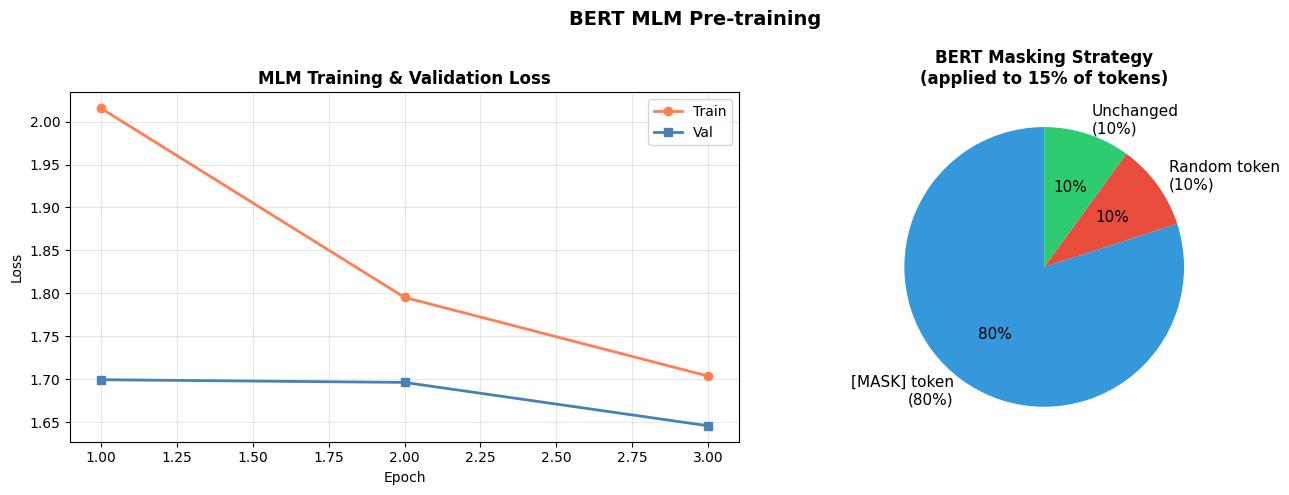

In [8]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS+1), train_losses, 'o-', color='coral',     label='Train', linewidth=2)
axes[0].plot(range(1, EPOCHS+1), val_losses,   's-', color='steelblue', label='Val',   linewidth=2)
axes[0].set_title('MLM Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Masking strategy pie chart
sizes  = [80, 10, 10]
labels = ['[MASK] token\n(80%)', 'Random token\n(10%)', 'Unchanged\n(10%)']
colors = ['#3498db', '#e74c3c', '#2ecc71']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('BERT Masking Strategy\n(applied to 15% of tokens)', fontweight='bold')

plt.suptitle('BERT MLM Pre-training', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab6_bert_mlm.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Explanation of MLM Objective

### What is Masked Language Modeling?
MLM is one of BERT's two pre-training objectives. **15% of input tokens are selected** for prediction. Of those:
- **80%** are replaced with `[MASK]` — the model must predict the original token.
- **10%** are replaced with a random token — forces the model not to rely only on `[MASK]` being special.
- **10%** are left unchanged — forces the model to keep good representations of non-masked tokens too.

### Why not mask 100%?
If all selected tokens were replaced with `[MASK]`, the model would learn to only update representations at `[MASK]` positions. The 10% random + 10% unchanged forces the model to maintain a useful representation for **every** token, not just masked ones.

### Loss function
```
Loss = CrossEntropy(predicted_token, original_token)
       — computed ONLY on the 15% masked positions
       — other positions have label = -100 (ignored)
```

### Why MLM enables transfer learning
By predicting masked tokens, BERT must learn:
- Syntax (grammar, word order)
- Semantics (word meaning, context)
- World knowledge ("The capital of France is **paris**")

These representations transfer powerfully to downstream tasks like sentiment, QA, and NER.